In [73]:
import numpy as np
import matplotlib.pyplot as plt
import copy,math

In [74]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0.0
    for i in range(m):
        f_wb_i=np.dot(X[i],w)+b
        cost+= (f_wb_i-y[i])**2
    cost/=(2*m)
    return cost

In [75]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    for i in range(m):
        err = (np.dot(X[i],w)+b)-y[i]
        for j in range(n):
            dj_dw[j]+=(err*X[i,j])
        dj_db += err
    dj_dw/=m
    dj_db/=m
    return dj_dw,dj_db

In [76]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,alpha,num_iters):
    J_history = []
    w=copy.deepcopy(w_in)
    b=b_in
    for i in range(num_iters):
        dj_dw,dj_db = gradient_function(X,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i<10000:
            J_history.append(cost_function(X,y,w,b))
        if i%math.ceil(num_iters/10)==0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}")
    return w,b,J_history

In [77]:
def run_gradient_descent_feng(X,y,iterations=1000,alpha=1e-6):
    m,n=X.shape
    initial_w=np.zeros(n)
    initial_b=0.
    w_out,b_out,hist_out = gradient_descent(X,y,initial_w,initial_b,compute_cost,compute_gradient,alpha,iterations)
    print(f"w and b found by gradient descent {w_out} {b_out}")
    return w_out,b_out

Iteration    0: Cost 10800.53
Iteration 1000: Cost   439.04
Iteration 2000: Cost   438.90
Iteration 3000: Cost   438.90
Iteration 4000: Cost   438.90
Iteration 5000: Cost   438.90
Iteration 6000: Cost   438.90
Iteration 7000: Cost   438.90
Iteration 8000: Cost   438.90
Iteration 9000: Cost   438.90
w and b found by gradient descent [19.] -55.999999999999126


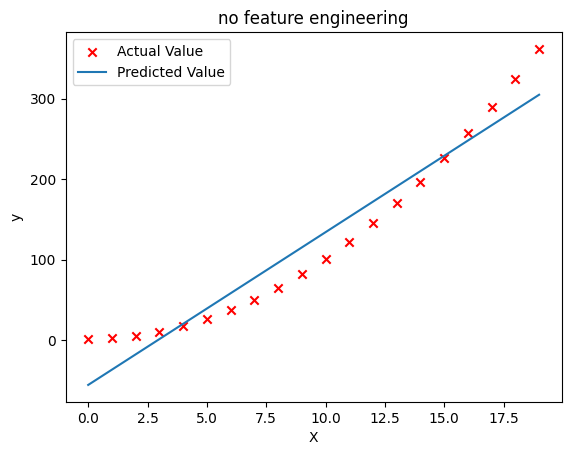

In [78]:
x=np.arange(0,20,1)
y=1+x**2
X = x.reshape(-1, 1)

model_w,model_b = run_gradient_descent_feng(X,y,10000,0.015)
plt.scatter(x,y,marker='x',c='r',label='Actual Value');plt.title("no feature engineering")
plt.plot(x,X@model_w+model_b,label='Predicted Value'); plt.xlabel("X");plt.ylabel("y");plt.legend();plt.show()

Iteration    0: Cost 13334.63
Iteration 10000: Cost     0.12
Iteration 20000: Cost     0.12
Iteration 30000: Cost     0.12
Iteration 40000: Cost     0.12
Iteration 50000: Cost     0.12
Iteration 60000: Cost     0.12
Iteration 70000: Cost     0.12
Iteration 80000: Cost     0.12
Iteration 90000: Cost     0.12
w and b found by gradient descent [1.00017727] 0.9596196827391282


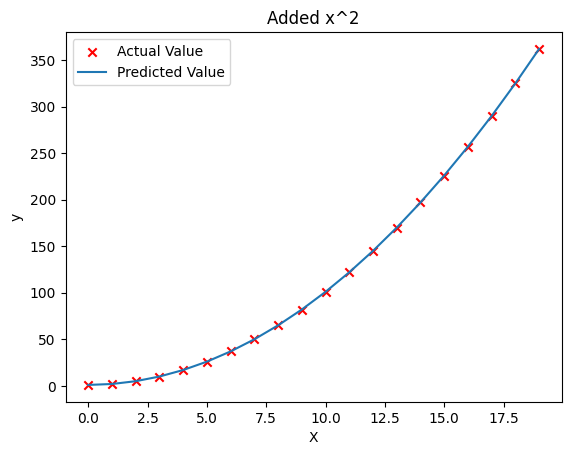

In [88]:
#As expected without feature engineering the line does not fit well so we should engineer the feature
x=np.arange(0,20,1)
y=1+x**2
X=x**2 #We take the squares of the data so now it would be x squared rather than x
X = X.reshape(-1, 1)

model_w,model_b = run_gradient_descent_feng(X,y,100000,0.00007)
plt.scatter(x,y,marker='x',c='r',label='Actual Value');plt.title("Added x^2")
plt.plot(x,X@model_w+model_b,label='Predicted Value'); plt.xlabel("X");plt.ylabel("y");plt.legend();plt.show()

In [80]:
#Try a new polynomial with cubed features
x=np.arange(0,20,1)
X=np.c_[x,x**2,x**3] #We added new engineered features

Iteration    0: Cost  1161.86
Iteration 1000: Cost   341.85
Iteration 2000: Cost   291.81
Iteration 3000: Cost   249.10
Iteration 4000: Cost   212.64
Iteration 5000: Cost   181.52
Iteration 6000: Cost   154.96
Iteration 7000: Cost   132.28
Iteration 8000: Cost   112.93
Iteration 9000: Cost    96.41
w and b found by gradient descent [0.08447334 0.54608322 0.02711841] 0.011039016941710573


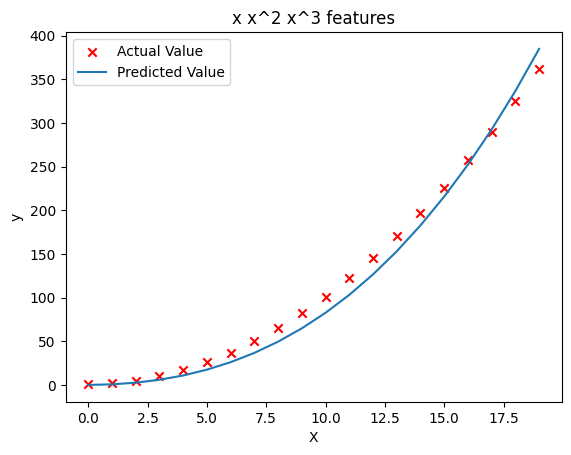

In [81]:
model_w,model_b = run_gradient_descent_feng(X,y,iterations=10000,alpha=1e-7)
plt.scatter(x,y,marker='x',c='r',label='Actual Value');plt.title("x x^2 x^3 features")
plt.plot(x,X@model_w+model_b,label='Predicted Value'); plt.xlabel("X");plt.ylabel("y");plt.legend();plt.show()
#We can understand how we must engineer the features by looking the weights of features found by gradient descent if it's too small it means it's not a correct feature

In [82]:
#Another way to understand the best fitting line is looking at the plot.
x=np.arange(0,20,1)
X=np.c_[x,x**2,x**3]
X_features = ['x','x^2','x^3']

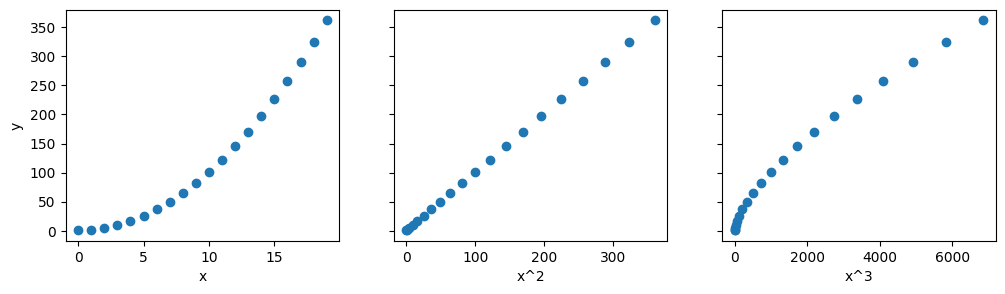

In [83]:
fig,ax = plt.subplots(1,3,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('y')
plt.plot();
#The best linear line is the x squared feature so its the correct one

In [84]:
#Since we use squares and cubes our data would have significantly different scales so we should normalize them
def zscore_normalize_features(X):
    mu=np.mean(X,axis=0)
    sigma=np.std(X,axis=0)
    X_normalized = (X-mu)/sigma
    return X_normalized,mu,sigma

In [85]:
x=np.arange(0,20,1)
X=np.c_[x,x**2,x**3]

print(f"Peak to peak range by column in raw: {np.ptp(X,axis=0)}")
X_norm,_,_ = zscore_normalize_features(X)
print(f"Peak to peak range by column in normalized: {np.ptp(X_norm,axis=0)}")

Peak to peak range by column in raw: [  19  361 6859]
Peak to peak range by column in normalized: [3.29501788 3.18076489 3.28307153]


Iteration    0: Cost  3852.70
Iteration 10000: Cost     0.00
Iteration 20000: Cost     0.00
Iteration 30000: Cost     0.00
Iteration 40000: Cost     0.00
Iteration 50000: Cost     0.00
Iteration 60000: Cost     0.00
Iteration 70000: Cost     0.00
Iteration 80000: Cost     0.00
Iteration 90000: Cost     0.00
w and b found by gradient descent [4.31320058e-12 1.13494714e+02 6.87376753e-12] 123.5


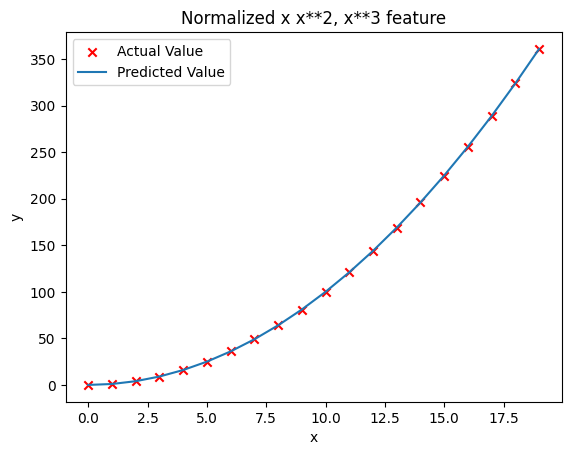

In [90]:
x = np.arange(0,20,1)
y = x**2

X = np.c_[x, x**2, x**3]
X = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent_feng(X_norm, y, iterations=100000, alpha=0.3)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X_norm@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

Iteration    0: Cost     0.22
Iteration 100000: Cost     0.03
Iteration 200000: Cost     0.03
Iteration 300000: Cost     0.03
Iteration 400000: Cost     0.03
Iteration 500000: Cost     0.03
Iteration 600000: Cost     0.03
Iteration 700000: Cost     0.03
Iteration 800000: Cost     0.03
Iteration 900000: Cost     0.03
w and b found by gradient descent [ -1.33565562 -10.00231728  24.77799625   5.96170981 -12.48587921
 -16.26275994  -9.50807133   0.59194813   8.70295901  11.9412625
   9.27097351   0.78896901 -12.81745188] -0.0072871948558396234


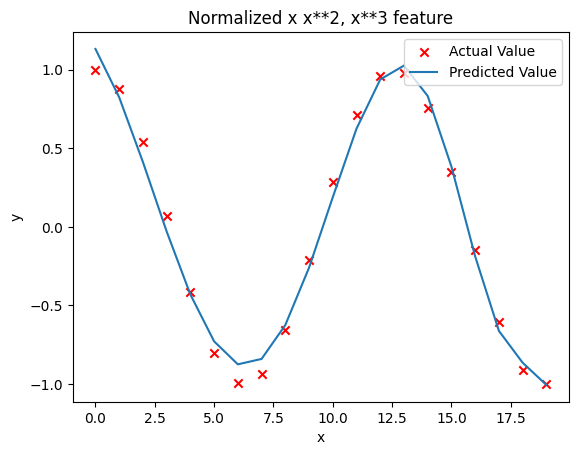

In [101]:
x=np.arange(0,20,1)
y=np.cos(x/2)

X=np.c_[x,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10,x**11,x**12,x**13]
X,_,_=zscore_normalize_features(X)

model_w,model_b=run_gradient_descent_feng(X,y,iterations=1000000,alpha=1e-1)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()
